(np.float64(-0.5), np.float64(370.5), np.float64(325.5), np.float64(-0.5))

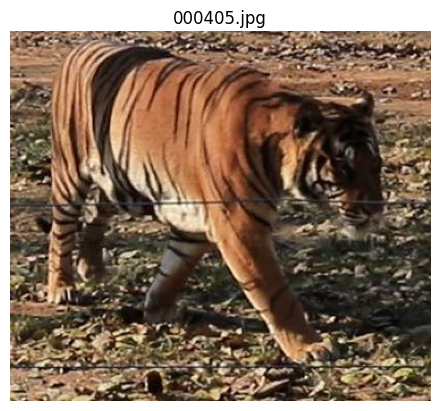

In [1]:
# Import required libraries
import os                           # For file and folder operations
from PIL import Image              # To open and process image files
import matplotlib.pyplot as plt    # For displaying images

# Path to training dataset folder
train_path = "./train_data"

# Get the first image filename from the training folder
img_name = os.listdir(train_path)[0]

# Create full image path by joining folder path + filename
img_path = os.path.join(train_path, img_name)

# Open the image using PIL
img = Image.open(img_path)

# Display image using matplotlib
plt.imshow(img)

# Show image filename as title
plt.title(img_name)

# Hide axis values/ticks for cleaner display
plt.axis("off")

# Render the image
plt.show()

In [2]:
import os  # Import os module for directory operations

# Count total number of images/files inside training dataset folder
train_count = len(os.listdir("./train_data"))

# Count total number of images/files inside testing dataset folder
test_count = len(os.listdir("./test_data"))

# Print number of training images
print("Train images:", train_count)

# Print number of testing images
print("Test images:", test_count)

Train images: 479
Test images: 405


In [3]:
import pandas as pd   # Import pandas library for data handling and CSV operations

# Read training label file (CSV) into a DataFrame
train_df = pd.read_csv("reid_list_train.csv")

# Display first 5 rows of the training dataset
train_df.head()

,250,003597.jpg
0,256,003523.jpg
1,171,003900.jpg
2,247,002636.jpg
3,238,002249.jpg
4,264,003370.jpg


In [4]:
from torch.utils.data import Dataset   # Base class for creating custom PyTorch datasets
from PIL import Image                 # For opening image files
import os                            # For file path operations

# Create custom dataset class for Tiger Re-Identification
class TigerDataset(Dataset):
    
    # Constructor method
    def __init__(self, csv_file, img_dir, transform=None):
        import pandas as pd
        
        # Read CSV file containing image names and labels
        self.df = pd.read_csv(csv_file)
        
        # Store image directory path
        self.img_dir = img_dir
        
        # Store image transformations (resize, tensor conversion, augmentation, etc.)
        self.transform = transform

    # Return total number of samples in dataset
    def __len__(self):
        return len(self.df)

    # Fetch one sample using index
    def __getitem__(self, idx):
        
        # Get image filename from first column of CSV
        img_name = self.df.iloc[idx, 0]
        
        # Get corresponding label from second column
        label = self.df.iloc[idx, 1]

        # Create full image path
        img_path = os.path.join(self.img_dir, img_name)
        
        # Open image and convert to RGB format
        image = Image.open(img_path).convert("RGB")

        # Apply transformations if provided
        if self.transform:
            image = self.transform(image)

        # Return processed image and label
        return image, label

In [5]:
import sys   # Import sys module to access Python interpreter information

# Print the full path of the currently active Python executable
# Useful for checking which environment/kernel is being used
print(sys.executable)

/home/user4/miniconda/envs/gpu-env/bin/python


In [6]:
# Install PyTorch, TorchVision, and TorchAudio with CUDA 11.8 support
# - pytorch      : Main deep learning framework
# - torchvision : Image datasets, transforms, pretrained vision models
# - torchaudio  : Audio utilities for PyTorch
# - pytorch-cuda=11.8 : Enables GPU acceleration using CUDA 11.8
# -c pytorch    : Use official PyTorch channel
# -c nvidia     : Use NVIDIA channel for CUDA packages

conda install pytorch torchvision torchaudio pytorch-cuda=11.8 -c pytorch -c nvidia

Jupyter detected...
2 channel Terms of Service accepted
Channels:
 - pytorch
 - nvidia
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.5.1
    latest version: 26.3.2

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [7]:
from torchvision import transforms   # Import image transformation utilities from torchvision

# Create a transformation pipeline for preprocessing images
transform = transforms.Compose([
    
    # Resize all images to 224 x 224 pixels
    # Required for most pretrained CNN models (ResNet, EfficientNet, etc.)
    transforms.Resize((224, 224)),
    
    # Convert PIL image to PyTorch tensor
    # Changes pixel values from [0,255] to [0,1]
    transforms.ToTensor(),
])

In [8]:
# Create training dataset object
train_dataset = TigerDataset(
    
    # CSV file containing training image names and labels
    csv_file="reid_list_train.csv",
    
    # Folder path containing training images
    img_dir="./train_data",
    
    # Apply preprocessing transforms (resize + tensor conversion)
    transform=transform
)

# Create testing dataset object
test_dataset = TigerDataset(
    
    # CSV file containing testing image names and labels
    csv_file="reid_list_test.csv",
    
    # Folder path containing testing images
    img_dir="./test_data",
    
    # Apply same preprocessing transforms
    transform=transform
)

In [9]:
from torch.utils.data import DataLoader   # Import DataLoader for batching and loading data

# Create DataLoader for training dataset
train_loader = DataLoader(
    train_dataset,      # Training dataset object
    batch_size=16,      # Load 16 images per batch
    shuffle=True        # Shuffle data each epoch for better learning
)

# Create DataLoader for testing dataset
test_loader = DataLoader(
    test_dataset,       # Testing dataset object
    batch_size=16       # Load 16 images per batch
    # shuffle=False by default for evaluation
)

In [10]:
import os   # Import os module for file and path operations

# Check whether the specified image file exists in the train_data folder
# Returns True if file is found, otherwise False
os.path.exists("./train_data/000405.jpg")

True

In [11]:
# Display the first 5 rows of the training DataFrame
# Helps inspect image filenames, labels, and dataset structure
train_df.head()

,250,003597.jpg
0,256,003523.jpg
1,171,003900.jpg
2,247,002636.jpg
3,238,002249.jpg
4,264,003370.jpg


In [12]:
from torch.utils.data import Dataset   # Base class for creating custom PyTorch datasets
from PIL import Image                 # For opening image files
import pandas as pd                  # For reading CSV files
import os                            # For file path operations

# Custom dataset class for Tiger Re-Identification
class TigerDataset(Dataset):

    # Initialize dataset
    def __init__(self, csv_file, img_dir, transform=None):
        
        # Read CSV file without header
        # Column 0 = Tiger identity label
        # Column 1 = Image filename
        self.df = pd.read_csv(csv_file, header=None)
        
        # Store image folder path
        self.img_dir = img_dir
        
        # Store transformations (resize, tensor conversion, augmentation, etc.)
        self.transform = transform

    # Return total number of samples
    def __len__(self):
        return len(self.df)

    # Get one image-label pair using index
    def __getitem__(self, idx):
        
        # Read tiger identity label from first column
        label = self.df.iloc[idx, 0]
        
        # Read image filename from second column
        img_name = self.df.iloc[idx, 1]

        # Build complete image path
        img_path = os.path.join(self.img_dir, img_name)
        
        # Open image and convert to RGB
        image = Image.open(img_path).convert("RGB")

        # Apply preprocessing if provided
        if self.transform:
            image = self.transform(image)

        # Return processed image and corresponding label
        return image, label

In [13]:
from torchvision import transforms   # Import torchvision image preprocessing tools

# Define image transformation pipeline
transform = transforms.Compose([
    
    # Resize each image to 224x224 pixels
    # Standard input size for many pretrained CNN models
    transforms.Resize((224, 224)),
    
    # Convert PIL image to PyTorch tensor
    # Pixel values scaled from [0,255] to [0,1]
    transforms.ToTensor(),
])

In [14]:
# Create dataset for training data
train_dataset = TigerDataset(
    
    # CSV file containing training labels and image filenames
    csv_file="reid_list_train.csv",
    
    # Folder containing training images
    img_dir="./train_data",
    
    # Apply preprocessing transformations
    transform=transform
)

# Create dataset for testing data
test_dataset = TigerDataset(
    
    # CSV file containing testing labels and image filenames
    csv_file="reid_list_test.csv",
    
    # Folder containing testing images
    img_dir="./test_data",
    
    # Apply same preprocessing transformations
    transform=transform
)

In [15]:
from torch.utils.data import DataLoader   # Import DataLoader for batching and efficient data loading

# Create DataLoader for training dataset
train_loader = DataLoader(
    train_dataset,      # Training dataset object
    batch_size=16,      # Number of images per batch
    shuffle=True        # Shuffle data each epoch to improve training
)

# Create DataLoader for testing dataset
test_loader = DataLoader(
    test_dataset,       # Testing dataset object
    batch_size=16       # Number of images per batch
    # shuffle=False by default during evaluation
)

In [16]:
import pandas as pd   # Import pandas for data handling
import os             # Import os for file path operations

# Read training CSV file
# header=None because file has no column names
# Assign custom column names
# Read both columns as string type
train_df = pd.read_csv(
    "reid_list_train.csv",
    header=None,
    names=["identity_id", "filename"],
    dtype={"identity_id": str, "filename": str}
)

# Remove rows where filename is missing (NaN)
train_df = train_df.dropna(subset=["filename"]).copy()

# Clean filename column:
# - Convert to string
# - Remove leading/trailing spaces
train_df["filename"] = train_df["filename"].astype(str).str.strip()

# Create full image path by joining folder path + filename
train_df["full_path"] = train_df["filename"].apply(
    lambda x: os.path.join("./train_data", x)
)

# Display first 5 rows of processed dataframe
train_df.head()

,identity_id,filename,full_path
0,250,003597.jpg,./train_data/003597.jpg
1,256,003523.jpg,./train_data/003523.jpg
2,171,003900.jpg,./train_data/003900.jpg
3,247,002636.jpg,./train_data/002636.jpg
4,238,002249.jpg,./train_data/002249.jpg


In [17]:
import pandas as pd   # Import pandas for reading and managing tabular data
import os             # Import os for file path handling

# Read testing CSV file
# header=None because file has no predefined column names
# Assign custom column names
# Read both columns as string type
test_df = pd.read_csv(
    "reid_list_test.csv",
    header=None,
    names=["identity_id", "filename"],
    dtype={"identity_id": str, "filename": str}
)

# Remove rows where filename is missing
test_df = test_df.dropna(subset=["filename"]).copy()

# Clean filename values:
# - Convert to string
# - Remove extra spaces before/after text
test_df["filename"] = test_df["filename"].astype(str).str.strip()

# Create full image path by combining folder path and filename
test_df["full_path"] = test_df["filename"].apply(
    lambda x: os.path.join("./test_data", x)
)

# Display first 5 rows of processed testing dataframe
test_df.head()

,identity_id,filename,full_path


In [18]:
# Print data types of each column in test dataframe
# Helps verify whether columns are string/object type
print(test_df.dtypes)

# Print data types of each column in train dataframe
# Useful for checking consistency between train and test data
print(train_df.dtypes)

# Display first 5 rows of test dataframe
# Helps inspect labels, filenames, and full image paths
print(test_df.head())

identity_id    object
filename       object
full_path      object
dtype: object
identity_id    object
filename       object
full_path      object
dtype: object
Empty DataFrame
Columns: [identity_id, filename, full_path]
Index: []


In [19]:
import pandas as pd   # Import pandas for CSV reading and data inspection

# Read original test CSV file without column names
raw_test = pd.read_csv("reid_list_test.csv", header=None)

# Find rows that contain at least one missing value (NaN)
# axis=1 checks across columns for each row
# any(axis=1) returns True for rows with missing data
print(raw_test[raw_test.isna().any(axis=1)])

Empty DataFrame
Columns: [0]
Index: []


In [20]:
import pandas as pd   # Import pandas for reading and processing CSV data
import os             # Import os for file path operations

# Read test CSV file containing only one column (filename)
# header=None because file has no column header
test_df = pd.read_csv(
    "reid_list_test.csv",
    header=None,
    names=["filename"]   # Assign single column name
)

# Clean dataframe:
# Remove empty rows
test_df = test_df.dropna().copy()

# Convert filenames to string and remove extra spaces
test_df["filename"] = test_df["filename"].astype(str).str.strip()

# Create complete image path by joining folder path and filename
test_df["full_path"] = test_df["filename"].apply(
    lambda x: os.path.join("./test_data", x)
)

# Display first 5 rows of processed test dataframe
test_df.head()

,filename,full_path
0,000999.jpg,./test_data/000999.jpg
1,001379.jpg,./test_data/001379.jpg
2,004776.jpg,./test_data/004776.jpg
3,002847.jpg,./test_data/002847.jpg
4,004309.jpg,./test_data/004309.jpg


In [21]:
import pandas as pd   # Import pandas for reading CSV files and data processing
import os             # Import os for file path operations

# Read training CSV file with two columns:
# Column 1 = identity label
# Column 2 = image filename
train_df = pd.read_csv(
    "reid_list_train.csv",
    header=None,
    names=["identity_id", "filename"]
)

# Clean identity_id column:
# Convert values to string and remove extra spaces
train_df["identity_id"] = train_df["identity_id"].astype(str).str.strip()

# Clean filename column:
# Convert values to string and remove extra spaces
train_df["filename"] = train_df["filename"].astype(str).str.strip()

# Create full image path by combining folder path and filename
train_df["full_path"] = train_df["filename"].apply(
    lambda x: os.path.join("./train_data", x)
)

In [22]:
# Add a new column named identity_id to test dataframe

# Assign -1 as a dummy label for all test images
# Used when true identities are unknown or not provided in test set
test_df["identity_id"] = -1

In [27]:
# Print number of rows and columns in training dataframe
# Output format: (rows, columns)
print("Train:", train_df.shape)

# Print number of rows and columns in testing dataframe
print("Test:", test_df.shape)

# Check whether first training image path exists
# Returns True if file is found, otherwise False
print(os.path.exists(train_df["full_path"].iloc[0]))

# Check whether first testing image path exists
print(os.path.exists(test_df["full_path"].iloc[0]))

Train: (263, 3)
Test: (1764, 3)
True
True


In [29]:
import torch   # Import PyTorch library

# Check whether CUDA-enabled GPU is available
# Stop execution if GPU is not detected
assert torch.cuda.is_available(), "GPU not available"

# Set computation device to GPU
device = torch.device("cuda")

# Print GPU model name
print("GPU:", torch.cuda.get_device_name(0))

# Print total GPU memory (VRAM) in GB
print(
    "VRAM:",
    f"{torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB"
)

GPU: NVIDIA RTX 2000 Ada Generation
VRAM: 16.7 GB


In [30]:
# ===============================
# Import Standard Python Libraries
# ===============================

import os                 # File and folder operations
import sys                # System-specific parameters and Python environment info
import random             # Random number generation
import math               # Mathematical functions
import logging            # Logging training progress / debug messages
import time               # Time measurement utilities
from collections import defaultdict   # Dictionary with default values

# ===============================
# Import Data Science Libraries
# ===============================

import numpy as np        # Numerical array operations
import pandas as pd       # DataFrame / CSV handling
import cv2                # OpenCV for image processing
from PIL import Image     # PIL for image loading
from tqdm import tqdm     # Progress bars for loops
from sklearn.model_selection import train_test_split  # Split dataset into train/validation

# ===============================
# Import PyTorch Libraries
# ===============================

import torch                              # Main PyTorch library
import torch.nn as nn                     # Neural network layers
import torch.nn.functional as F          # Activation functions / tensor ops
import torchvision.transforms as T       # Image preprocessing transforms
from torch.utils.data import Dataset, DataLoader, Sampler  # Dataset utilities
from torch.utils.tensorboard import SummaryWriter          # TensorBoard logging

# ===============================
# Import TIMM Library
# ===============================

import timm   # Pretrained image models (EfficientNet, ViT, ResNet, etc.)

I0000 00:00:1776490099.407167   81692 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776490103.102595   81692 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/user4/miniconda/envs/gpu-env/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.18) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Pyth

In [31]:
# Create configuration class to store all experiment settings
class CFG:
    
    # ===============================
    # Dataset Paths
    # ===============================
    
    train_dir = "./train_data"          # Folder containing training images
    test_dir = "./test_data"            # Folder containing testing images
    
    train_csv = "./reid_list_train.csv" # CSV file for train labels + filenames
    test_csv = "./reid_list_test.csv"   # CSV file for test image list

    # ===============================
    # Output Paths
    # ===============================
    
    cache_dir = "./fma_cache"          # Folder for cached features/files
    ckpt_dir = "./checkpoints"         # Folder to save trained model weights
    log_dir = "./runs"                 # Folder for TensorBoard logs

    # ===============================
    # Reproducibility / Input Size
    # ===============================
    
    seed = 42                          # Random seed for reproducibility
    img_size = 256                     # Input image size (256x256)

    # ===============================
    # Model Settings
    # ===============================
    
    backbone = "vit_small_patch16_224" # Vision Transformer backbone model
    mu = 0.5                           # Custom hyperparameter (loss weighting etc.)
    lam = 0.1                          # Regularization / custom parameter

    # ===============================
    # Training Hyperparameters
    # ===============================
    
    epochs = 20                        # Total training epochs
    batch_P = 4                        # Number of identities per batch
    batch_K = 4                        # Images per identity
    lr = 0.001                         # Learning rate
    momentum = 0.9                     # SGD momentum
    weight_decay = 5e-4               # L2 regularization
    margin = 0.3                       # Triplet loss margin
    label_smooth = 0.1                # Label smoothing factor
    num_workers = 2                    # DataLoader worker processes

    # ===============================
    # Runtime Options
    # ===============================
    
    fp16 = True                        # Use mixed precision training
    no_cache = False                   # Disable cache if True
    resume = None                      # Resume training checkpoint path
    eval_every = 5                     # Run evaluation every 5 epochs


# Create configuration object
cfg = CFG()

In [32]:
# Function to create logging system
def setup_logging(ckpt_dir):
    
    # Create checkpoint folder if it does not exist
    os.makedirs(ckpt_dir, exist_ok=True)
    
    # Define log file path
    log_file = os.path.join(ckpt_dir, "train.log")

    # Create logger object named "adafreq"
    logger = logging.getLogger("adafreq")
    
    # Set logging level to INFO
    logger.setLevel(logging.INFO)
    
    # Remove old handlers to avoid duplicate logs
    logger.handlers.clear()

    # Define log message format
    fmt = logging.Formatter(
        "[%(asctime)s] %(levelname)s — %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S"
    )

    # Console output handler (prints logs in notebook/terminal)
    ch = logging.StreamHandler(sys.stdout)
    ch.setFormatter(fmt)
    logger.addHandler(ch)

    # File output handler (saves logs to train.log)
    fh = logging.FileHandler(log_file)
    fh.setFormatter(fmt)
    logger.addHandler(fh)

    # Return configured logger
    return logger


# Function to fix random seeds for reproducibility
def set_seed(seed):
    
    # Python random seed
    random.seed(seed)
    
    # NumPy random seed
    np.random.seed(seed)
    
    # PyTorch CPU seed
    torch.manual_seed(seed)
    
    # PyTorch GPU seed (all CUDA devices)
    torch.cuda.manual_seed_all(seed)

In [33]:
# Function to apply Frequency Mix Augmentation (FMA) using NumPy
def fma_numpy(img_bgr, alpha=None):
    
    # If alpha is not given, choose a random value between 0.0 and 0.5
    # alpha controls the size of the mixed square region
    if alpha is None:
        alpha = random.uniform(0.0, 0.5)

    # Get image height and width
    rows, cols = img_bgr.shape[:2]
    
    # Compute image center coordinates
    cx, cy = cols // 2, rows // 2
    
    # Create coordinate arrays centered at image middle
    xs = np.arange(cols) - cx
    ys = np.arange(rows) - cy
    X, Y = np.meshgrid(xs, ys)
    
    # Create high-pass filter mask in frequency domain
    # Keeps higher-frequency details and suppresses low-frequency components
    hp = 1.0 - np.exp(-(X**2 + Y**2) / (2 * 30.0**2))

    # Determine square patch size based on alpha
    h_sq = max(1, int(np.sqrt(alpha) * rows))
    w_sq = max(1, int(np.sqrt(alpha) * cols))
    
    # Randomly choose top-left corner of square patch
    r0 = random.randint(0, max(rows - h_sq, 0))
    c0 = random.randint(0, max(cols - w_sq, 0))
    
    # Create binary mixing mask
    # 1 inside square patch, 0 elsewhere
    M = np.zeros((rows, cols), np.float32)
    M[r0:r0+h_sq, c0:c0+w_sq] = 1.0

    # Store processed channels here
    out = []
    
    # Process each color channel separately
    for ch in range(3):
        # Convert image channel to float
        c = img_bgr[:, :, ch].astype(np.float32)
        
        # Apply 2D Fourier Transform and shift zero frequency to center
        Fsh = np.fft.fftshift(np.fft.fft2(c))
        
        # Apply high-pass filter to emphasize fine details
        Fsh_h = Fsh * hp
        
        # Mix original and high-pass filtered frequency components
        # Square region keeps original frequency, बाकी image uses filtered frequency
        Fsh_mix = (1 - M) * Fsh_h + M * Fsh
        
        # Convert back to spatial domain
        res = np.abs(np.fft.ifft2(np.fft.ifftshift(Fsh_mix)))
        
        # Normalize result back to 0–255 range
        lo, hi = res.min(), res.max()
        res = (res - lo) / (hi - lo + 1e-8) * 255.0
        
        # Clip pixel values and store channel
        out.append(np.clip(res, 0, 255))
    
    # Stack processed channels back into 3-channel image
    return np.stack(out, axis=2).astype(np.uint8)


# Function to precompute and save FMA-augmented training images
def precache_fma(df_train, cache_dir, logger):
    
    # Create cache directory if it does not exist
    os.makedirs(cache_dir, exist_ok=True)
    
    # Counter for already existing cached files
    already = 0

    # Loop through all rows in training dataframe with progress bar
    for _, row in tqdm(df_train.iterrows(), total=len(df_train), desc="Pre-caching FMA", ncols=80):
        
        # Create destination filename for cached image
        # Replace "/" to avoid invalid nested paths
        dst = os.path.join(cache_dir, row["filename"].replace("/", "_"))
        
        # Skip if cached file already exists
        if os.path.isfile(dst):
            already += 1
            continue

        # Read original training image using OpenCV
        img = cv2.imread(row["full_path"])
        
        # If image is loaded successfully, apply FMA and save it
        if img is not None:
            cv2.imwrite(dst, fma_numpy(img), [cv2.IMWRITE_JPEG_QUALITY, 95])

    # Log summary of caching process
    logger.info(f"FMA cache: {already} skipped, {len(df_train)-already} newly written → {cache_dir}")

In [34]:
# Function to load labeled training data and unlabeled public test data
def load_train_and_public_test(train_csv, train_dir, test_csv, test_dir):
    
    # ===============================
    # Load Training CSV
    # ===============================
    
    train_df = pd.read_csv(
        train_csv,
        header=None,
        names=["identity_id", "filename"]
    )

    # Clean training columns
    train_df["identity_id"] = train_df["identity_id"].astype(str).str.strip()
    train_df["filename"] = train_df["filename"].astype(str).str.strip()

    # Create full path for each training image
    train_df["full_path"] = train_df["filename"].apply(
        lambda x: os.path.join(train_dir, x)
    )

    # Keep only rows where image file exists
    train_df = train_df[
        train_df["full_path"].apply(os.path.isfile)
    ].reset_index(drop=True)

    # ===============================
    # Load Public Test CSV
    # ===============================
    
    public_test_df = pd.read_csv(
        test_csv,
        header=None,
        names=["filename"]
    )

    # Clean filename column
    public_test_df["filename"] = public_test_df["filename"].astype(str).str.strip()

    # Create full path for each test image
    public_test_df["full_path"] = public_test_df["filename"].apply(
        lambda x: os.path.join(test_dir, x)
    )

    # Keep only rows where image file exists
    public_test_df = public_test_df[
        public_test_df["full_path"].apply(os.path.isfile)
    ].reset_index(drop=True)

    # Return processed train and test dataframes
    return train_df, public_test_df


# Load train and test datasets using config paths
train_df, public_test_df = load_train_and_public_test(
    cfg.train_csv, cfg.train_dir,
    cfg.test_csv, cfg.test_dir
)

# Print training dataset shape (rows, columns)
print("Labeled train:", train_df.shape)

# Print test dataset shape (rows, columns)
print("Unlabeled test:", public_test_df.shape)

# Print number of unique tiger identities in training set
print("Train IDs:", train_df["identity_id"].nunique())

# Display first 5 rows of training dataframe
train_df.head()

Labeled train: (263, 3)
Unlabeled test: (404, 2)
Train IDs: 101


,identity_id,filename,full_path
0,201,000109.jpg,./train_data/000109.jpg
1,91,000361.jpg,./train_data/000361.jpg
2,153,000612.jpg,./train_data/000612.jpg
3,64,000356.jpg,./train_data/000356.jpg
4,261,000447.jpg,./train_data/000447.jpg


In [35]:
# Function to split labeled training data into train and validation sets
def make_train_val_split(train_df, val_ratio=0.2, seed=42):
    
    # Count number of images available for each identity
    counts = train_df["identity_id"].value_counts()
    
    # Keep only identities having at least 2 images
    # Needed so same identity can appear multiple times for training/validation
    valid_ids = counts[counts >= 2].index.tolist()

    # Filter dataset to valid identities only
    df_ok = train_df[
        train_df["identity_id"].isin(valid_ids)
    ].reset_index(drop=True)

    # Split unique identity IDs into train IDs and validation IDs
    # Identity-wise split avoids same tiger appearing in both sets
    train_ids, val_ids = train_test_split(
        sorted(df_ok["identity_id"].unique()),
        test_size=val_ratio,
        random_state=seed
    )

    # Create training subset using selected train identities
    df_train = df_ok[
        df_ok["identity_id"].isin(train_ids)
    ].reset_index(drop=True)

    # Create validation subset using selected validation identities
    df_val = df_ok[
        df_ok["identity_id"].isin(val_ids)
    ].reset_index(drop=True)

    # Return split dataframes
    return df_train, df_val


# Create train/validation split using config settings
df_train, df_val = make_train_val_split(
    train_df,
    val_ratio=0.2,
    seed=cfg.seed
)

# Print train split size and number of unique identities
print(
    "Train split:",
    df_train.shape,
    "IDs:",
    df_train["identity_id"].nunique()
)

# Print validation split size and number of unique identities
print(
    "Val split  :",
    df_val.shape,
    "IDs:",
    df_val["identity_id"].nunique()
)

Train split: (173, 3) IDs: 52
Val split  : (54, 3) IDs: 13


In [36]:
# Custom dataset class for ATRW tiger re-identification training/validation
class ATRWDataset(Dataset):
    def __init__(self, df, cache_dir=None, is_train=True, img_size=256):
        # Directory containing cached FMA images (optional)
        self.cache_dir = cache_dir
        
        # Flag to indicate training mode or evaluation mode
        self.is_train = is_train

        # Create mapping from original identity_id to continuous numeric labels
        # Example: {"tiger_01":0, "tiger_02":1, ...}
        uid2lbl = {u: i for i, u in enumerate(sorted(df["identity_id"].unique()))}
        
        # Store image full paths
        self.paths = df["full_path"].tolist()
        
        # Store image filenames only
        self.fnames = df["filename"].tolist()
        
        # Convert identity IDs into numeric class labels
        self.labels = [uid2lbl[u] for u in df["identity_id"]]
        
        # Total number of unique classes
        self.num_classes = len(uid2lbl)

        # Standard ImageNet normalization values
        mean = [0.485, 0.456, 0.406]
        std = [0.229, 0.224, 0.225]

        # Training image transformation pipeline
        train_tf = T.Compose([
            T.Resize((img_size, img_size)),          # Resize image
            T.RandomHorizontalFlip(),                # Random left-right flip
            T.RandomRotation(15),                    # Random rotation up to 15 degrees
            T.ColorJitter(brightness=0.4, contrast=0.4),  # Random brightness/contrast change
            T.Pad(10),                               # Add padding around image
            T.CenterCrop(img_size),                  # Crop back to target size
            T.ToTensor(),                            # Convert PIL image to tensor
            T.Normalize(mean, std),                  # Normalize pixel values
        ])

        # Evaluation / validation transformation pipeline
        eval_tf = T.Compose([
            T.Resize((img_size, img_size)),          # Resize image
            T.ToTensor(),                            # Convert PIL image to tensor
            T.Normalize(mean, std),                  # Normalize pixel values
        ])

        # Select train or eval transforms based on mode
        self.tf = train_tf if is_train else eval_tf

    # Return total number of samples
    def __len__(self):
        return len(self.paths)

    # Get one sample by index
    def __getitem__(self, idx):
        # Numeric class label
        label = self.labels[idx]
        
        # Read original image using OpenCV (BGR format)
        img_orig = cv2.imread(self.paths[idx])
        if img_orig is None:
            raise RuntimeError(f"Cannot read: {self.paths[idx]}")

        # Convert original image from BGR to RGB
        orig_rgb = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)
        
        # Apply transforms to original image
        x_orig = self.tf(Image.fromarray(orig_rgb))

        # During evaluation, return only original image and label
        if not self.is_train:
            return x_orig, torch.tensor(label, dtype=torch.long)

        # For training, also prepare FMA / high-frequency image
        hf_src = None
        if self.cache_dir:
            # Build cached augmented image path
            c = os.path.join(self.cache_dir, self.fnames[idx].replace("/", "_"))
            if os.path.isfile(c):
                hf_src = c

        # If cached version exists, load it; otherwise generate FMA image on the fly
        img_hf = cv2.imread(hf_src) if hf_src else fma_numpy(img_orig)
        
        # Convert augmented image from BGR to RGB
        hf_rgb = cv2.cvtColor(img_hf, cv2.COLOR_BGR2RGB)
        
        # Apply transforms to augmented image
        x_hf = self.tf(Image.fromarray(hf_rgb))

        # Return original image, FMA image, and label
        return x_orig, x_hf, label


# Dataset for inference / test-time prediction
class InferenceDataset(Dataset):
    def __init__(self, df, img_size=256):
        # Reset dataframe index for safe access
        self.df = df.reset_index(drop=True)
        
        # Store full image paths
        self.paths = self.df["full_path"].tolist()
        
        # Store filenames for output/reference
        self.filenames = self.df["filename"].tolist()

        # Standard ImageNet normalization values
        mean = [0.485, 0.456, 0.406]
        std = [0.229, 0.224, 0.225]

        # Inference transformation pipeline
        self.tf = T.Compose([
            T.Resize((img_size, img_size)),   # Resize image
            T.ToTensor(),                     # Convert to tensor
            T.Normalize(mean, std),           # Normalize pixel values
        ])

    # Return number of inference samples
    def __len__(self):
        return len(self.paths)

    # Load one test image
    def __getitem__(self, idx):
        # Read image
        img = cv2.imread(self.paths[idx])
        if img is None:
            raise RuntimeError(f"Cannot read: {self.paths[idx]}")
        
        # Convert BGR to RGB
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Apply transforms
        x = self.tf(Image.fromarray(img))
        
        # Return transformed image and filename
        return x, self.filenames[idx]


# Custom collate function for training batches
def train_collate(batch):
    # Stack original images into one tensor of shape [B, C, H, W]
    x_o = torch.stack([b[0] for b in batch])
    
    # Stack high-frequency / FMA images into one tensor
    x_h = torch.stack([b[1] for b in batch])
    
    # Convert labels into LongTensor
    lbls = torch.tensor([b[2] for b in batch], dtype=torch.long)
    
    # Return batch tensors
    return x_o, x_h, lbls


# PK Sampler for person / animal ReID training
# Selects P identities and K images per identity in each batch
class PKSampler(Sampler):
    def __init__(self, labels, P=8, K=4):
        # Number of images per identity
        self.K = K
        
        # Dictionary: label -> list of sample indices
        self.ld = defaultdict(list)
        for i, l in enumerate(labels):
            self.ld[l].append(i)
        
        # List of unique labels
        self.ls = list(self.ld.keys())
        
        # Number of identities per batch
        self.P = min(P, len(self.ls))

    # Generate sampling order
    def __iter__(self):
        # Copy and shuffle identity labels
        ids = self.ls.copy()
        random.shuffle(ids)
        
        out = []
        
        # Process labels in chunks of size P
        for s in range(0, len(ids), self.P):
            chunk = ids[s:s+self.P]
            
            # If last chunk is smaller than P, pad with random identities
            while len(chunk) < self.P:
                chunk.append(random.choice(ids))
            
            # For each identity, randomly sample K images
            for l in chunk:
                out.extend(random.choices(self.ld[l], k=self.K))
        
        # Return iterator over sampled indices
        return iter(out)

    # Total number of samples per epoch
    def __len__(self):
        return math.ceil(len(self.ls) / self.P) * self.P * self.K

In [37]:
# Define AdaFreq model for tiger re-identification
class AdaFreqModel(nn.Module):
    def __init__(self, num_classes, backbone_name, img_size=256, mu=0.5):
        super().__init__()
        
        # Store fraction used to select important patches
        self.mu = mu

        # Create Vision Transformer backbone from timm
        # pretrained=True loads ImageNet pretrained weights
        self.backbone = timm.create_model(
            backbone_name,
            pretrained=True,
            img_size=img_size
        )

        # Embedding dimension of transformer features
        D = self.backbone.embed_dim
        
        # Number of image patches for ViT
        # For patch size 16, total patches = (img_size/16)^2
        n_patches = (img_size // 16) ** 2
        
        # Number of top important patches to select
        self.Z = max(1, int(mu * n_patches))

        # ===============================
        # Original-image branch
        # ===============================
        
        self.bn_o1 = nn.BatchNorm1d(D)         # Normalize CLS token features
        self.fc_o = nn.Linear(D, 512)          # Reduce feature size to 512
        self.bn_o2 = nn.BatchNorm1d(512)       # Normalize projected embedding
        self.cls_o = nn.Linear(512, num_classes)  # Classification layer

        # ===============================
        # High-frequency-image branch
        # ===============================
        
        self.bn_h1 = nn.BatchNorm1d(D)         # Normalize CLS token features
        self.fc_h = nn.Linear(D, 512)          # Reduce feature size to 512
        self.bn_h2 = nn.BatchNorm1d(512)       # Normalize projected embedding
        self.cls_h = nn.Linear(512, num_classes)  # Classification layer

        # Placeholder to store input to the last transformer block
        self._blk_in = None
        
        # Register hook to capture input tensor before the last transformer block
        self.backbone.blocks[-1].register_forward_pre_hook(
            lambda m, inp: setattr(self, "_blk_in", inp[0].detach())
        )

    # Function to select top important patches using attention scores
    def _ods_select(self):
        # Input to last transformer block saved by hook
        x = self._blk_in
        
        # Access attention module of last transformer block
        atm = self.backbone.blocks[-1].attn
        
        # B = batch size, Np1 = number of tokens including CLS, D = embedding dimension
        B, Np1, D = x.shape
        
        # Number of attention heads
        H = atm.num_heads
        
        # Dimension per head
        hd = D // H

        # Compute qkv projection without gradients
        with torch.no_grad():
            qkv = atm.qkv(x)

        # Reshape qkv to separate query, key, value and heads
        qkv = qkv.reshape(B, Np1, 3, H, hd).permute(2, 0, 3, 1, 4)
        q, k, _ = qkv.unbind(0)

        # Scaled dot-product attention from CLS token to patch tokens
        scale = hd ** -0.5
        scores = (q[:, :, 0:1, :] @ k[:, :, 1:, :].transpose(-2, -1)) * scale
        
        # Convert scores into attention probabilities
        scores = scores.softmax(dim=-1).squeeze(2)
        
        # Average attention scores across heads
        scores = scores.mean(dim=1)
        
        # Select indices of top-Z most important patches
        topz = scores.argsort(dim=-1, descending=True)[:, :self.Z]
        return topz

    # Forward pass
    def forward(self, x_orig, x_hf=None):
        # ===============================
        # Original image forward pass
        # ===============================
        
        # Extract transformer features
        feats_o = self.backbone.forward_features(x_orig)
        
        # CLS token feature
        cls_o = feats_o[:, 0, :]
        
        # Patch token features
        patch_o = feats_o[:, 1:, :]

        # Select important patch indices
        topz = self._ods_select()

        # Project CLS feature to normalized embedding space
        co = F.normalize(self.bn_o2(self.fc_o(self.bn_o1(cls_o))), dim=1)
        
        # Classification logits for original image
        lo = self.cls_o(co)

        # If only original image is provided, return original branch output
        if x_hf is None:
            return co, lo

        # ===============================
        # High-frequency image forward pass
        # ===============================
        
        # Extract transformer features for high-frequency image
        feats_h = self.backbone.forward_features(x_hf)
        
        # CLS token feature
        cls_h = feats_h[:, 0, :]
        
        # Patch token features
        patch_h = feats_h[:, 1:, :]

        # Prepare index tensor for gathering selected patches
        B, Z, D = topz.shape[0], topz.shape[1], patch_o.shape[-1]
        idx = topz.unsqueeze(-1).expand(B, Z, D)
        
        # Gather selected important patches from original branch
        sel_o = patch_o.gather(1, idx)
        
        # Gather corresponding selected patches from high-frequency branch
        sel_h = patch_h.gather(1, idx)

        # Project high-frequency CLS feature to normalized embedding space
        ch = F.normalize(self.bn_h2(self.fc_h(self.bn_h1(cls_h))), dim=1)
        
        # Classification logits for high-frequency image
        lh = self.cls_h(ch)

        # Return embeddings, logits, and selected patch features
        return co, lo, ch, lh, sel_o, sel_h

In [38]:
# Batch-hard triplet loss for metric learning
def batch_hard_triplet_loss(emb, labels, margin=0.3):
    
    # Compute pairwise Euclidean distance matrix between all embeddings
    dist = torch.cdist(emb, emb, p=2)
    
    # Initialize total loss on same device as embeddings
    loss = torch.tensor(0.0, device=emb.device)

    # Loop through each sample in the batch
    for i in range(len(labels)):
        
        # Positive mask: same label as anchor
        pm = (labels == labels[i]).clone()
        
        # Exclude anchor itself from positive set
        pm[i] = False
        
        # Negative mask: different label from anchor
        nm = labels != labels[i]

        # Skip if no valid positive or negative samples exist
        if pm.sum() == 0 or nm.sum() == 0:
            continue

        # Hardest positive = farthest positive sample
        # Hardest negative = nearest negative sample
        # Triplet loss = max(0, hardest_pos - hardest_neg + margin)
        loss += torch.relu(dist[i][pm].max() - dist[i][nm].min() + margin)

    # Return average loss over batch
    return loss / len(labels)


# Feature equilibrium loss to align selected original and high-frequency patches
def feature_equilibrium_loss(sel_o, sel_h):
    
    # Difference between selected patch features
    diff = sel_o - sel_h
    
    # Absolute difference
    abs_d = diff.abs()
    
    # Apply Huber loss element-wise
    # Small errors use squared loss, large errors use linear loss
    huber = torch.where(abs_d < 1, 0.5 * diff.pow(2), abs_d - 0.5)
    
    # Average across embedding dimension and patch dimension, then sum over batch
    return huber.mean(dim=-1).mean(dim=-1).sum()


# Extract embeddings and labels from labeled dataset
def extract_features_labeled(model, loader, device):
    model.eval()   # Set model to evaluation mode
    embs, lbls = [], []

    # Disable gradient computation for faster inference
    with torch.no_grad():
        for batch in loader:
            # Move images to GPU/CPU
            imgs = batch[0].to(device, non_blocking=True)
            
            # Get labels
            labels = batch[1]
            
            # Forward pass through model
            co, _ = model(imgs)
            
            # Store embeddings and labels on CPU
            embs.append(co.cpu())
            lbls.append(labels.cpu())

    # Concatenate all batches into single tensors
    return torch.cat(embs), torch.cat(lbls)


# Extract embeddings and filenames from unlabeled dataset
def extract_features_unlabeled(model, loader, device):
    model.eval()   # Set model to evaluation mode
    all_embs = []
    all_names = []

    # Disable gradient computation
    with torch.no_grad():
        for imgs, names in loader:
            # Move images to device
            imgs = imgs.to(device, non_blocking=True)
            
            # Forward pass
            co, _ = model(imgs)
            
            # Store embeddings and filenames
            all_embs.append(co.cpu())
            all_names.extend(list(names))

    # Return all embeddings and corresponding filenames
    return torch.cat(all_embs), all_names


# Compute standard ReID evaluation metrics:
# Rank-1 Accuracy, mAP, and mINP
def compute_reid_metrics(query_embs, query_lbls, gallery_embs, gallery_lbls):
    
    # Compute pairwise distance matrix between query and gallery embeddings
    dist_mat = torch.cdist(query_embs, gallery_embs, p=2).numpy()
    
    # Convert labels to NumPy arrays
    q_labels = query_lbls.numpy()
    g_labels = gallery_lbls.numpy()

    # Initialize metric counters
    rank1 = 0
    APs = []
    INPs = []

    # Evaluate each query image
    for i in range(len(q_labels)):
        
        # Sort gallery indices by ascending distance (closest first)
        order = np.argsort(dist_mat[i])
        
        # Match vector: 1 if gallery label matches query label, else 0
        matches = (g_labels[order] == q_labels[i]).astype(np.float32)
        
        # Number of correct matches in gallery
        num_pos = int(matches.sum())

        # Skip query if no positive match exists in gallery
        if num_pos == 0:
            continue

        # Rank-1 correct if top retrieved gallery image is a match
        if matches[0] == 1:
            rank1 += 1

        # Compute cumulative true positives
        cum_tp = np.cumsum(matches)
        
        # Precision at each rank
        prec = cum_tp / (np.arange(len(matches)) + 1)
        
        # Average Precision for this query
        APs.append((prec * matches).sum() / num_pos)

        # Find rank position of last correct match
        last_pos = np.where(matches == 1)[0][-1]
        
        # INP = number of positives / rank of last positive
        INPs.append(num_pos / (last_pos + 1))

    # Avoid division by zero if no valid queries
    denom = max(1, len(APs))
    
    # Return metrics in percentage form
    return rank1 / denom * 100, np.mean(APs) * 100, np.mean(INPs) * 100

In [39]:
# Function to split validation set into Query and Gallery sets for ReID evaluation
def make_query_gallery(df_val, seed=42):
    
    # Store selected query rows
    query_rows = []
    
    # Store selected gallery rows
    gallery_rows = []

    # Group validation dataframe by tiger identity
    for identity, grp in df_val.groupby("identity_id"):
        
        # Shuffle images of current identity
        grp = grp.sample(frac=1, random_state=seed).reset_index(drop=True)

        # Select first image as Query image
        # One query image per identity
        query_rows.append(grp.iloc[0])

        # Remaining images go to Gallery set
        for i in range(1, len(grp)):
            gallery_rows.append(grp.iloc[i])

    # Convert query rows list into DataFrame
    query_df = pd.DataFrame(query_rows).reset_index(drop=True)
    
    # Convert gallery rows list into DataFrame
    gallery_df = pd.DataFrame(gallery_rows).reset_index(drop=True)

    # Return Query and Gallery datasets
    return query_df, gallery_df


# Create Query and Gallery split from validation set
query_df, gallery_df = make_query_gallery(df_val, seed=cfg.seed)

# Print shapes of datasets
print("Query shape  :", query_df.shape)
print("Gallery shape:", gallery_df.shape)

# Show first 5 rows of Query set
print(query_df.head())

# Show first 5 rows of Gallery set
print(gallery_df.head())

Query shape  : (13, 3)
Gallery shape: (41, 3)
  identity_id    filename                full_path
0           0  000584.jpg  ./train_data/000584.jpg
1         132  000524.jpg  ./train_data/000524.jpg
2         153  000718.jpg  ./train_data/000718.jpg
3         168  000370.jpg  ./train_data/000370.jpg
4         181  000279.jpg  ./train_data/000279.jpg
  identity_id    filename                full_path
0           0  000384.jpg  ./train_data/000384.jpg
1         132  000327.jpg  ./train_data/000327.jpg
2         132  000172.jpg  ./train_data/000172.jpg
3         153  000678.jpg  ./train_data/000678.jpg
4         153  000612.jpg  ./train_data/000612.jpg


In [40]:
# Create logger and initialize experiment logging
logger = setup_logging(cfg.ckpt_dir)

# Set random seed for reproducibility
set_seed(cfg.seed)

# Precompute and save FMA-augmented training images if caching is enabled
if not cfg.no_cache:
    precache_fma(df_train, cfg.cache_dir, logger)

# Create training dataset
# Uses original + high-frequency/FMA images during training
train_ds = ATRWDataset(
    df_train,
    cache_dir=None if cfg.no_cache else cfg.cache_dir,
    is_train=True,
    img_size=cfg.img_size
)

# Create query dataset for validation evaluation
# Uses only original images, no augmentation pair
query_ds = ATRWDataset(
    query_df,
    cache_dir=None,
    is_train=False,
    img_size=cfg.img_size
)

# Create gallery dataset for validation evaluation
gallery_ds = ATRWDataset(
    gallery_df,
    cache_dir=None,
    is_train=False,
    img_size=cfg.img_size
)

# Create public test dataset for inference / prediction
public_test_ds = InferenceDataset(
    public_test_df,
    img_size=cfg.img_size
)

# Set P and K values for PK sampling
# P = number of identities per batch
# K = number of images per identity
P = min(cfg.batch_P, train_ds.num_classes)
K = cfg.batch_K

# Create PK sampler for ReID training batches
sampler = PKSampler(train_ds.labels, P=P, K=K)

# DataLoader for training
# batch_size = P * K so each batch contains P identities with K images each
train_loader = DataLoader(
    train_ds,
    batch_size=P * K,
    sampler=sampler,
    num_workers=cfg.num_workers,
    pin_memory=True,
    drop_last=True,
    persistent_workers=(cfg.num_workers > 0),
    collate_fn=train_collate
)

# DataLoader for query set
query_loader = DataLoader(
    query_ds,
    batch_size=128,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=True,
    persistent_workers=(cfg.num_workers > 0)
)

# DataLoader for gallery set
gallery_loader = DataLoader(
    gallery_ds,
    batch_size=128,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=True,
    persistent_workers=(cfg.num_workers > 0)
)

# DataLoader for public unlabeled test set
public_test_loader = DataLoader(
    public_test_ds,
    batch_size=128,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=True,
    persistent_workers=(cfg.num_workers > 0)
)

# Print total number of batches in each loader
print("Train batches :", len(train_loader))
print("Query batches :", len(query_loader))
print("Gallery batches:", len(gallery_loader))
print("Public test batches:", len(public_test_loader))

# Print total number of training classes / identities
print("Train classes:", train_ds.num_classes)

Pre-caching FMA: 100%|█████████████████████| 173/173 [00:00<00:00, 34345.37it/s]

[2026-04-18 10:58:34] INFO — FMA cache: 173 skipped, 0 newly written → ./fma_cache
Train batches : 13
Query batches : 1
Gallery batches: 1
Public test batches: 4
Train classes: 52


In [41]:
# Create AdaFreq model and move it to GPU / selected device
model = AdaFreqModel(
    
    # Number of tiger identity classes
    num_classes=train_ds.num_classes,
    
    # Backbone network name (ViT / CNN from timm)
    backbone_name=cfg.backbone,
    
    # Input image size
    img_size=cfg.img_size,
    
    # Fraction used for selecting important ODS patches
    mu=cfg.mu

).to(device)

# Calculate total number of trainable + non-trainable parameters
# Convert to millions (M)
n_params = sum(p.numel() for p in model.parameters()) / 1e6

# Print total model size
print(f"Model params: {n_params:.1f}M")

# Print number of selected ODS patches
print(f"ODS Z patches: {model.Z}")

Model params: 22.5M
ODS Z patches: 128


In [42]:
# Cross Entropy loss for classification branch
# label_smoothing helps reduce overconfidence and improves generalization
ce_fn = nn.CrossEntropyLoss(
    label_smoothing=cfg.label_smooth
)

# Create SGD optimizer
optimizer = torch.optim.SGD(
    
    # Model parameters to optimize
    model.parameters(),
    
    # Initial learning rate
    lr=cfg.lr,
    
    # Momentum accelerates convergence
    momentum=cfg.momentum,
    
    # Weight decay = L2 regularization
    weight_decay=cfg.weight_decay
)

# Cosine Annealing learning rate scheduler
# Gradually decreases LR following cosine curve
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    
    optimizer,          # Optimizer to update
    
    T_max=cfg.epochs,   # Total scheduler cycle = total epochs
    
    eta_min=1e-6        # Minimum learning rate
)

# Mixed Precision Gradient Scaler
# Used only when fp16 training is enabled on CUDA GPU
scaler = torch.amp.GradScaler("cuda") if cfg.fp16 else None

In [43]:
# Initialize starting epoch for fresh training
start_epoch = 0

# Initialize best loss with infinity
# Used to track best checkpoint during training
best_loss = float("inf")

# Check if resume checkpoint path is provided
# and file exists
if cfg.resume is not None and os.path.isfile(cfg.resume):

    # Load checkpoint file to current device (CPU/GPU)
    ckpt = torch.load(cfg.resume, map_location=device)

    # Load saved model weights
    model.load_state_dict(ckpt["model_state"])

    # Load saved optimizer state
    optimizer.load_state_dict(ckpt["optim_state"])

    # Restore epoch number
    start_epoch = ckpt["epoch"]

    # Restore best recorded loss if available
    best_loss = ckpt.get("loss", float("inf"))

    # Advance scheduler to correct epoch position
    for _ in range(start_epoch):
        scheduler.step()

    # Print resume information
    print(f"Resumed from epoch {start_epoch}, best loss {best_loss:.4f}")

In [44]:
# Set default starting epoch to 0
# Means training begins from first epoch unless checkpoint is loaded
start_epoch = 0

# Initialize best validation/training loss as infinity
# Any real loss value during training will be lower than this
best_loss = float("inf")

# Resume training only if:
# 1. Checkpoint path is provided
# 2. File exists
if cfg.resume is not None and os.path.isfile(cfg.resume):

    # Load checkpoint file onto current device (CPU/GPU)
    ckpt = torch.load(cfg.resume, map_location=device)

    # Restore model weights
    model.load_state_dict(ckpt["model_state"])

    # Restore optimizer state (learning rate, momentum, etc.)
    optimizer.load_state_dict(ckpt["optim_state"])

    # Restore epoch number to continue training
    start_epoch = ckpt["epoch"]

    # Restore best saved loss if available
    best_loss = ckpt.get("loss", float("inf"))

    # Move scheduler forward to correct epoch position
    for _ in range(start_epoch):
        scheduler.step()

    # Print checkpoint resume information
    print(f"Resumed from epoch {start_epoch}, best loss {best_loss:.4f}")

In [45]:
# Create TensorBoard writer for logging losses, metrics, and learning rate
writer = SummaryWriter(log_dir=cfg.log_dir)

# Log training start information
logger.info("Starting training...")
logger.info(f"Epochs: {start_epoch+1} → {cfg.epochs}")

# Main training loop over epochs
for epoch in range(start_epoch, cfg.epochs):
    model.train()                  # Set model to training mode
    t0 = time.time()               # Start timer for epoch

    # Initialize running totals for losses
    tot_loss = 0.0
    tot_id_o = 0.0
    tot_tri_o = 0.0
    tot_id_h = 0.0
    tot_tri_h = 0.0
    tot_lf = 0.0
    n_batch = 0

    # Loop through training batches
    for x_orig, x_hf, lbls in train_loader:
        # Move batch data to GPU/selected device
        x_orig = x_orig.to(device, non_blocking=True)
        x_hf = x_hf.to(device, non_blocking=True)
        lbls = lbls.to(device, non_blocking=True)

        # Clear previous gradients
        optimizer.zero_grad(set_to_none=True)

        # ===============================
        # Mixed precision training branch
        # ===============================
        if scaler:
            with torch.amp.autocast("cuda"):
                # Forward pass through model
                co, lo, ch, lh, sel_o, sel_h = model(x_orig, x_hf)

                # Losses for original-image branch
                l_id_o = ce_fn(lo, lbls)                              # classification loss
                l_tri_o = batch_hard_triplet_loss(co, lbls, cfg.margin)  # triplet loss

                # Losses for high-frequency-image branch
                l_id_h = ce_fn(lh, lbls)                              # classification loss
                l_tri_h = batch_hard_triplet_loss(ch, lbls, cfg.margin)  # triplet loss

                # Feature equilibrium loss between selected patches
                l_f = feature_equilibrium_loss(sel_o, sel_h)

                # Total loss
                loss = l_id_o + l_tri_o + l_id_h + l_tri_h + cfg.lam * l_f

            # Backpropagation with gradient scaling
            scaler.scale(loss).backward()

            # Unscale gradients before clipping
            scaler.unscale_(optimizer)

            # Clip gradients to stabilize training
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            # Optimizer step with scaler
            scaler.step(optimizer)
            scaler.update()

        # ===============================
        # Standard FP32 training branch
        # ===============================
        else:
            # Forward pass
            co, lo, ch, lh, sel_o, sel_h = model(x_orig, x_hf)

            # Original branch losses
            l_id_o = ce_fn(lo, lbls)
            l_tri_o = batch_hard_triplet_loss(co, lbls, cfg.margin)

            # High-frequency branch losses
            l_id_h = ce_fn(lh, lbls)
            l_tri_h = batch_hard_triplet_loss(ch, lbls, cfg.margin)

            # Patch alignment loss
            l_f = feature_equilibrium_loss(sel_o, sel_h)

            # Total loss
            loss = l_id_o + l_tri_o + l_id_h + l_tri_h + cfg.lam * l_f

            # Backpropagation
            loss.backward()

            # Gradient clipping
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            # Update model parameters
            optimizer.step()

        # Accumulate losses for epoch summary
        tot_loss += loss.item()
        tot_id_o += l_id_o.item()
        tot_tri_o += l_tri_o.item()
        tot_id_h += l_id_h.item()
        tot_tri_h += l_tri_h.item()
        tot_lf += l_f.item()
        n_batch += 1

    # Update learning rate scheduler after each epoch
    scheduler.step()

    # Compute average losses for the epoch
    avg = tot_loss / max(n_batch, 1)
    avg_ido = tot_id_o / max(n_batch, 1)
    avg_trio = tot_tri_o / max(n_batch, 1)
    avg_idh = tot_id_h / max(n_batch, 1)
    avg_trih = tot_tri_h / max(n_batch, 1)
    avg_lf = tot_lf / max(n_batch, 1)

    # Compute elapsed time and current learning rate
    elapsed = time.time() - t0
    cur_lr = scheduler.get_last_lr()[0]

    # Log epoch summary
    logger.info(
        f"Ep [{epoch+1:3d}/{cfg.epochs}]  "
        f"Loss:{avg:.4f}  "
        f"IDo:{avg_ido:.3f} Trio:{avg_trio:.3f}  "
        f"IDh:{avg_idh:.3f} Trih:{avg_trih:.3f}  "
        f"LF:{avg_lf:.3f}  "
        f"LR:{cur_lr:.2e}  "
        f"[{elapsed:.0f}s]"
    )

    # Write losses and LR to TensorBoard
    writer.add_scalar("Loss/total", avg, epoch + 1)
    writer.add_scalar("Loss/ID_orig", avg_ido, epoch + 1)
    writer.add_scalar("Loss/Tri_orig", avg_trio, epoch + 1)
    writer.add_scalar("Loss/ID_hf", avg_idh, epoch + 1)
    writer.add_scalar("Loss/Tri_hf", avg_trih, epoch + 1)
    writer.add_scalar("Loss/Equil", avg_lf, epoch + 1)
    writer.add_scalar("LR", cur_lr, epoch + 1)

    # ===============================
    # Validation step every eval_every epochs
    # ===============================
    if (epoch + 1) % cfg.eval_every == 0:
        # Extract embeddings for query and gallery sets
        query_embs, query_lbls = extract_features_labeled(model, query_loader, device)
        gallery_embs, gallery_lbls = extract_features_labeled(model, gallery_loader, device)

        # Compute ReID metrics
        r1, mAP, mINP = compute_reid_metrics(
            query_embs, query_lbls,
            gallery_embs, gallery_lbls
        )

        # Log validation results
        logger.info(f"  ► Val Rank-1:{r1:.2f}%  Val mAP:{mAP:.2f}%  Val mINP:{mINP:.2f}%")

        # Save validation metrics to TensorBoard
        writer.add_scalar("Eval/Rank1", r1, epoch + 1)
        writer.add_scalar("Eval/mAP", mAP, epoch + 1)
        writer.add_scalar("Eval/mINP", mINP, epoch + 1)

    # Check whether current model is best so far
    is_best = avg < best_loss
    if is_best:
        best_loss = avg

    # Save training state
    state = {
        "epoch": epoch + 1,
        "model_state": model.state_dict(),
        "optim_state": optimizer.state_dict(),
        "loss": avg
    }

    # Ensure checkpoint directory exists
    os.makedirs(cfg.ckpt_dir, exist_ok=True)

    # Save best model checkpoint
    if is_best:
        p = os.path.join(cfg.ckpt_dir, "best.pth")
        torch.save(state, p)
        logger.info(f"  ★ Best checkpoint saved → {p}")

    # Save periodic checkpoint every eval_every epochs
    if (epoch + 1) % cfg.eval_every == 0:
        p = os.path.join(cfg.ckpt_dir, f"epoch_{epoch+1}.pth")
        torch.save(state, p)
        logger.info(f"  → Checkpoint saved: {p}")

# Close TensorBoard writer after training
writer.close()

# Log training completion summary
logger.info(f"Training complete. Best loss: {best_loss:.4f}")

[2026-04-18 10:58:36] INFO — Starting training...
[2026-04-18 10:58:36] INFO — Epochs: 1 → 20
[2026-04-18 10:58:39] INFO — Ep [  1/20]  Loss:10.8362  IDo:3.955 Trio:0.276  IDh:3.950 Trih:0.476  LF:21.784  LR:9.94e-04  [3s]
[2026-04-18 10:58:41] INFO —   ★ Best checkpoint saved → ./checkpoints/best.pth
[2026-04-18 10:58:43] INFO — Ep [  2/20]  Loss:10.5912  IDo:3.952 Trio:0.239  IDh:3.951 Trih:0.459  LF:19.902  LR:9.76e-04  [2s]
[2026-04-18 10:58:44] INFO —   ★ Best checkpoint saved → ./checkpoints/best.pth
[2026-04-18 10:58:46] INFO — Ep [  3/20]  Loss:10.2954  IDo:3.955 Trio:0.188  IDh:3.951 Trih:0.402  LF:17.988  LR:9.46e-04  [2s]
[2026-04-18 10:58:47] INFO —   ★ Best checkpoint saved → ./checkpoints/best.pth
[2026-04-18 10:58:49] INFO — Ep [  4/20]  Loss:10.0227  IDo:3.955 Trio:0.201  IDh:3.949 Trih:0.344  LF:15.739  LR:9.05e-04  [2s]
[2026-04-18 10:58:50] INFO —   ★ Best checkpoint saved → ./checkpoints/best.pth
[2026-04-18 10:58:51] INFO — Ep [  5/20]  Loss:9.8027  IDo:3.953 Trio:

In [46]:
# Extract feature embeddings and labels from Query dataset
query_embs, query_lbls = extract_features_labeled(
    model,          # Trained AdaFreq model
    query_loader,   # Query DataLoader
    device          # GPU / CPU device
)

# Extract feature embeddings and labels from Gallery dataset
gallery_embs, gallery_lbls = extract_features_labeled(
    model,            # Trained model
    gallery_loader,   # Gallery DataLoader
    device
)

# Compute ReID evaluation metrics:
# Rank-1 Accuracy, mean Average Precision, mean Inverse Negative Penalty
r1, mAP, mINP = compute_reid_metrics(
    query_embs, query_lbls,
    gallery_embs, gallery_lbls
)

# Print formatted validation results
print("=" * 50)
print(f"Validation Rank-1 : {r1:.2f}%")
print(f"Validation mAP    : {mAP:.2f}%")
print(f"Validation mINP   : {mINP:.2f}%")
print("=" * 50)

Validation Rank-1 : 92.31%
Validation mAP    : 92.71%
Validation mINP   : 90.51%


In [47]:
# Extract feature embeddings and filenames from unlabeled public test dataset
public_embs, public_names = extract_features_unlabeled(
    model,               # Trained AdaFreq model
    public_test_loader,  # DataLoader for public test images
    device               # GPU / CPU device
)

# Print shape of extracted embedding matrix
# Format: (number_of_images, feature_dimension)
print("Public test embeddings shape:", public_embs.shape)

# Print total number of public test image files processed
print("Number of public test files :", len(public_names))

Public test embeddings shape: torch.Size([404, 512])
Number of public test files : 404


In [48]:
# Convert PyTorch tensor embeddings to NumPy array
emb_np = public_embs.numpy()

# Create DataFrame from embedding vectors
# Each row = one image, each column = one feature dimension
submission_df = pd.DataFrame(emb_np)

# Insert filename column as first column
# Helps map embeddings back to corresponding images
submission_df.insert(0, "filename", public_names)

# Save embeddings to CSV file
# index=False prevents row numbers from being saved
submission_df.to_csv("public_test_embeddings.csv", index=False)

# Confirm file creation
print("Saved: public_test_embeddings.csv")

Saved: public_test_embeddings.csv


In [49]:
# Create full path to best saved model checkpoint
best_ckpt_path = os.path.join(cfg.ckpt_dir, "best.pth")

# Check whether best checkpoint file exists
# Returns True if found, otherwise False
print("Best checkpoint exists:", os.path.isfile(best_ckpt_path))

# Print checkpoint file location
print("Best checkpoint path  :", best_ckpt_path)

Best checkpoint exists: True
Best checkpoint path  : ./checkpoints/best.pth


In [50]:
import numpy as np                               # Numerical operations
from sklearn.metrics.pairwise import cosine_similarity  # Compute cosine similarity

# Function to find top-K most similar images for a given query image
def find_top_k(query_idx, embeddings, filenames, top_k=5):
    
    # Select query image embedding and reshape to 2D array
    # Required format: (1, feature_dimension)
    query = embeddings[query_idx].reshape(1, -1)

    # Compute cosine similarity between query embedding and all embeddings
    sims = cosine_similarity(query, embeddings)[0]

    # Sort similarity scores in descending order
    # Highest similarity first
    idxs = np.argsort(-sims)

    # Print query image filename
    print(f"\n🔍 Query Image: {filenames[query_idx]}\n")

    # Store retrieval results
    results = []

    # Skip first result because it is the query image itself
    # Return next top_k most similar images
    for i in idxs[1:top_k+1]:
        results.append((filenames[i], sims[i]))
    
    # Return list of (filename, similarity_score)
    return results

In [51]:
import matplotlib.pyplot as plt   # Library for plotting images
from PIL import Image             # For opening image files
import os                         # For file path handling

# Function to display query image and top matched results
def show_results(query_idx, results, base_path="./test_data"):
    
    # Create figure with horizontal layout
    # Width adjusts based on number of retrieved results
    plt.figure(figsize=(12, 3))

    # ===============================
    # Show Query Image
    # ===============================
    
    # Open query image using filename from public_names list
    query_img = Image.open(
        os.path.join(base_path, public_names[query_idx])
    )

    # First subplot reserved for query image
    plt.subplot(1, len(results) + 1, 1)
    plt.imshow(query_img)
    plt.title("Query")
    plt.axis("off")

    # ===============================
    # Show Retrieved Similar Images
    # ===============================
    
    for i, (fname, score) in enumerate(results):
        
        # Open retrieved image
        img = Image.open(os.path.join(base_path, fname))
        
        # Display image in next subplot positions
        plt.subplot(1, len(results) + 1, i + 2)
        plt.imshow(img)
        
        # Show similarity score as title
        plt.title(f"{score:.2f}")
        plt.axis("off")

    # Render all images
    plt.show()


🔍 Query Image: 000224.jpg



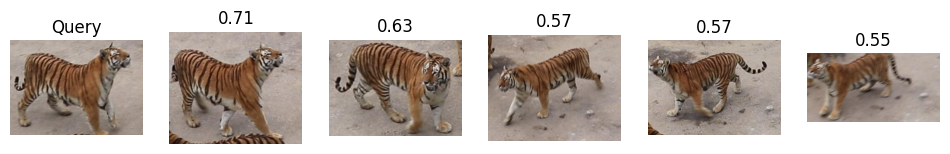

In [52]:
# Convert PyTorch tensor embeddings to NumPy array
# Move tensor to CPU first (required before .numpy())
embeddings = public_embs.cpu().numpy()

# Select query image index
# You can change this value to test different images
query_idx = 10

# Find top-5 most similar images to selected query image
results = find_top_k(
    query_idx,      # Query image index
    embeddings,     # Feature embeddings
    public_names,   # Corresponding filenames
    top_k=5         # Number of similar results to retrieve
)

# Display query image + retrieved similar images
show_results(query_idx, results)


🔍 Query Image: 000065.jpg



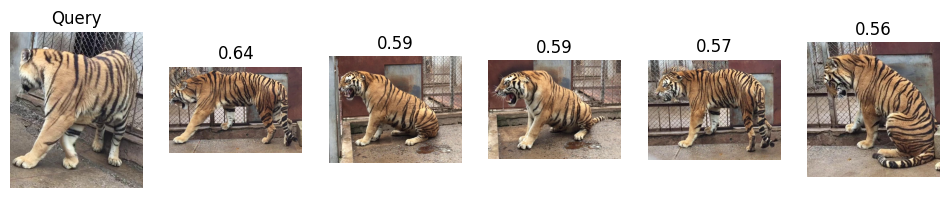


🔍 Query Image: 001060.jpg



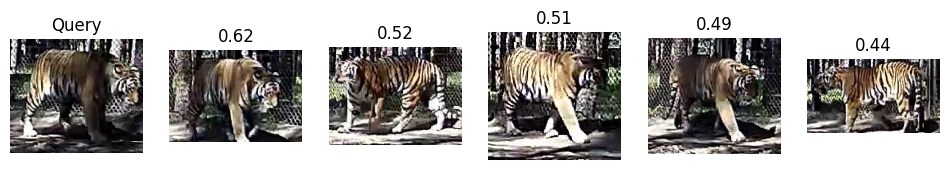


🔍 Query Image: 000544.jpg



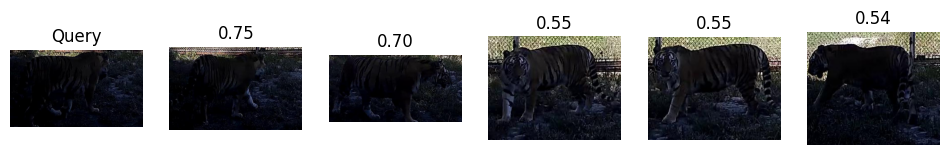

In [53]:
# Convert PyTorch tensor embeddings to NumPy array
# Required for cosine similarity search
embeddings = public_embs.cpu().numpy()

# Test multiple query images using selected indices
for idx in [5, 20, 50]:
    
    # Find top similar images for current query image
    results = find_top_k(
        idx,            # Current query index
        embeddings,     # Feature vectors
        public_names    # Image filenames
    )
    
    # Display query image and retrieved matches
    show_results(idx, results)

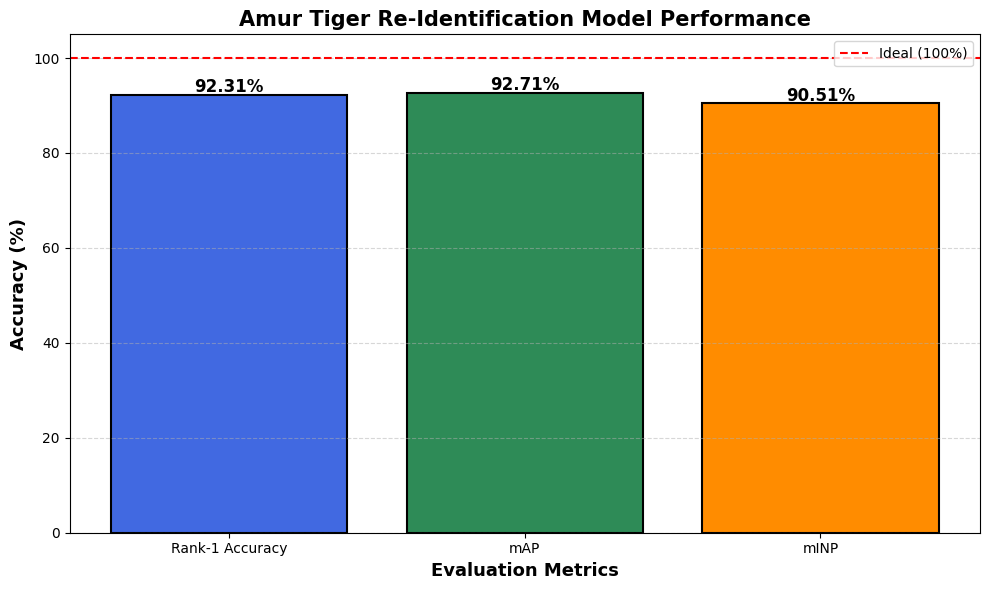

In [54]:
import matplotlib.pyplot as plt   # Library for plotting graphs
import numpy as np                # Numerical operations

# Store ReID evaluation metrics in dictionary
metrics = {
    "Rank-1 Accuracy": 92.31,   # Top-1 retrieval accuracy
    "mAP": 92.71,               # Mean Average Precision
    "mINP": 90.51               # Mean Inverse Negative Penalty
}

# Extract metric names and values separately
labels = list(metrics.keys())
values = list(metrics.values())

# Create figure with custom size
plt.figure(figsize=(10, 6))

# Define bar colors
colors = ['royalblue', 'seagreen', 'darkorange']

# Draw bar chart
bars = plt.bar(
    labels,
    values,
    color=colors,
    edgecolor='black',
    linewidth=1.5
)

# Add percentage labels above each bar
for bar in bars:
    height = bar.get_height()
    
    plt.text(
        bar.get_x() + bar.get_width() / 2,   # Center of bar
        height + 0.5,                        # Slightly above bar
        f'{height:.2f}%',                    # Text label
        ha='center',
        fontsize=12,
        fontweight='bold'
    )

# Draw reference line for ideal 100% score
plt.axhline(
    y=100,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label='Ideal (100%)'
)

# Set Y-axis range
plt.ylim(0, 105)

# Add axis labels
plt.ylabel("Accuracy (%)", fontsize=13, fontweight='bold')
plt.xlabel("Evaluation Metrics", fontsize=13, fontweight='bold')

# Add graph title
plt.title(
    "Amur Tiger Re-Identification Model Performance",
    fontsize=15,
    fontweight='bold'
)

# Add horizontal grid lines
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Show legend
plt.legend()

# Adjust spacing automatically
plt.tight_layout()

# Display graph
plt.show()

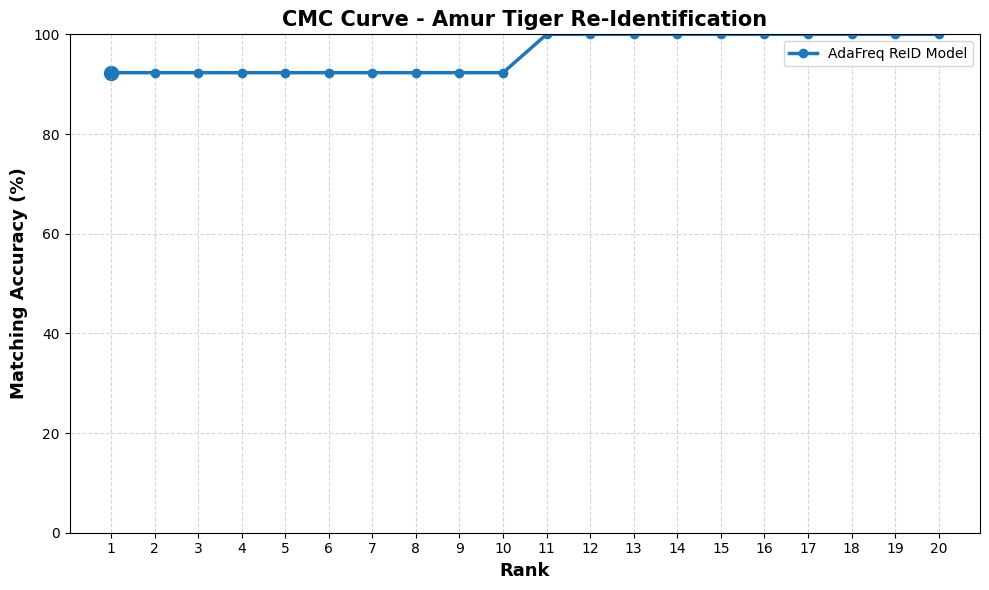

In [55]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# Function to compute CMC Curve for ReID
# ==========================================================
# query_embs   : Query feature vectors
# query_lbls   : Query identity labels
# gallery_embs : Gallery feature vectors
# gallery_lbls : Gallery identity labels
# max_rank     : Maximum rank to evaluate (Rank-1 ... Rank-K)
# ==========================================================
def compute_cmc(query_embs, query_lbls, gallery_embs, gallery_lbls, max_rank=20):

    # Compute Euclidean distance between query and gallery embeddings
    # Smaller distance = more similar
    dist_mat = np.linalg.norm(
        query_embs[:, None] - gallery_embs[None, :],
        axis=2
    )

    # Number of queries
    num_q = len(query_lbls)

    # Store cumulative matches
    cmc = np.zeros(max_rank)

    # Process each query image
    for i in range(num_q):

        # Sort gallery images by ascending distance
        order = np.argsort(dist_mat[i])

        # Check where gallery labels match query label
        matches = (gallery_lbls[order] == query_lbls[i]).astype(int)

        # If no correct match exists, skip query
        if matches.sum() == 0:
            continue

        # Find first correct match rank
        first_match_rank = np.where(matches == 1)[0][0]

        # If rank within max_rank, update CMC
        if first_match_rank < max_rank:
            cmc[first_match_rank:] += 1

    # Convert counts to percentage
    cmc = cmc / num_q * 100

    return cmc


# ==========================================================
# Convert PyTorch tensors to NumPy arrays
# ==========================================================
q_emb = query_embs.cpu().numpy()
q_lbl = query_lbls.cpu().numpy()

g_emb = gallery_embs.cpu().numpy()
g_lbl = gallery_lbls.cpu().numpy()

# ==========================================================
# Compute CMC values
# ==========================================================
cmc_scores = compute_cmc(
    q_emb, q_lbl,
    g_emb, g_lbl,
    max_rank=20
)

# ==========================================================
# Plot CMC Curve
# ==========================================================
plt.figure(figsize=(10, 6))

# X-axis = Rank positions
ranks = np.arange(1, 21)

# Plot curve
plt.plot(
    ranks,
    cmc_scores,
    marker='o',
    linewidth=2.5,
    label="AdaFreq ReID Model"
)

# Highlight Rank-1 score
plt.scatter(1, cmc_scores[0], s=100)

# Labels and title
plt.xlabel("Rank", fontsize=13, fontweight='bold')
plt.ylabel("Matching Accuracy (%)", fontsize=13, fontweight='bold')
plt.title("CMC Curve - Amur Tiger Re-Identification", fontsize=15, fontweight='bold')

# Grid
plt.grid(True, linestyle='--', alpha=0.5)

# X-axis ticks
plt.xticks(ranks)

# Y-axis limit
plt.ylim(0, 100)

# Legend
plt.legend()

# Show graph
plt.tight_layout()
plt.show()